# Performance Analysis

## Setup

In [1]:
import os

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import xarray as xr
import rioxarray as rxr

In [5]:
import rasterio

In [6]:
import matplotlib.cm as cm
import matplotlib.colors as colors

In [7]:
from scipy.stats import spearmanr

In [8]:
from rasterio import features
from shapely.geometry import box

In [9]:
DATA_DIR = '../data'

In [10]:
FIGURES_DIR = '../saved_figures'

In [11]:
def tileId_to_epsg(tileId):
    zone = int(tileId[:2])
    return f'EPSG:326{zone}'

In [12]:
data_tiles_all = {}
data_tiles_dir = os.path.join(DATA_DIR, 'data_tiles')
for f in os.listdir(data_tiles_dir):
    if not f.startswith('data_tile'):
        continue

    tile_id = f[10:15]

    f_full = os.path.join(data_tiles_dir, f)
    
    data_tiles_all[tile_id] = xr.open_dataset(f_full, chunks={})
    data_tiles_all[tile_id].chunk({'y': 2048, 'x': 2048})
    tile_crs = tileId_to_epsg(tile_id)
    data_tiles_all[tile_id].rio.write_crs(tile_crs, inplace=True)

In [14]:
pred_dir = os.path.join(DATA_DIR, 'predictions/wxgb')

In [15]:
pred_tiles_all = {}
for f in os.listdir(pred_dir):
    if not f.endswith('pred.tif'):
        continue

    tile_id = f[:5]
    f_full = os.path.join(pred_dir, f)

    # Load GeoTIFF
    da = rxr.open_rasterio(f_full, masked=True).squeeze()  # squeeze removes the extra band dim

    # Assign CRS explicitly based on tile ID if needed
    tile_crs = tileId_to_epsg(tile_id)
    da = da.rio.write_crs(tile_crs, inplace=False)

    # Store in dict
    pred_tiles_all[tile_id] = da

## Continuous Boyce Index (CBI)

In [30]:
def continuous_boyce_index(predicted_raster_values, presence_values, n_bins=20):
    # Remove NaNs
    predicted_raster_values = np.array(predicted_raster_values)
    presence_values = np.array(presence_values)
    predicted_raster_values = predicted_raster_values[~np.isnan(predicted_raster_values)]
    presence_values = presence_values[~np.isnan(presence_values)]

    # Define bin edges
    bins = np.linspace(predicted_raster_values.min(), predicted_raster_values.max(), n_bins + 1)
    
    # Compute frequency of background and presence in each bin
    freq_pred = np.histogram(predicted_raster_values, bins=bins)[0] / len(predicted_raster_values)
    freq_pres = np.histogram(presence_values, bins=bins)[0] / len(presence_values)
    
    # Avoid divide-by-zero
    mask = freq_pred > 0
    freq_ratio = freq_pres[mask] / freq_pred[mask]
    mid_bin_values = (bins[:-1] + bins[1:]) / 2
    mid_bin_values = mid_bin_values[mask]
    
    # Spearman correlation between predicted suitability and frequency ratio
    cbi, _ = spearmanr(mid_bin_values, freq_ratio)
    return cbi


In [33]:
def plot_boyce_curve(predicted_raster_values, presence_values, n_bins=20):
    bins = np.linspace(predicted_raster_values.min(), predicted_raster_values.max(), n_bins + 1)
    freq_pred = np.histogram(predicted_raster_values, bins=bins)[0] / len(predicted_raster_values)
    freq_pres = np.histogram(presence_values, bins=bins)[0] / len(presence_values)
    mask = freq_pred > 0
    freq_ratio = freq_pres[mask] / freq_pred[mask]
    mid_bin_values = (bins[:-1] + bins[1:]) / 2
    mid_bin_values = mid_bin_values[mask]

    plt.plot(mid_bin_values, freq_ratio, marker='o')
    plt.axhline(1, color='grey', linestyle='--')
    plt.xlabel("Predicted presence probability")
    plt.ylabel("Frequency ratio (Presence / Expected)")
    plt.title("Boyce Curve")
    # plt.savefig(os.path.join(FIGURES_DIR, 'boyce_xgb'))
    plt.show()


### Pooled CBI

In [24]:
da_pred

<xarray.DataArray (y: 5001, x: 4632)> Size: 93MB
[23164632 values with dtype=float32]
Coordinates:
    band         int64 8B 1
  * x            (x) float64 37kB 5e+05 5e+05 5e+05 ... 5.926e+05 5.926e+05
  * y            (y) float64 40kB 6.6e+06 6.6e+06 6.6e+06 ... 6.5e+06 6.5e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      pred

In [38]:
bg_values = []
presence_vals = []

for tile_grid in tg_test:
    tileId = tile_grid[:5]
    grid_id = int(tile_grid[5:])

    ds = data_tiles_all[tileId]

    if not hasattr(ds, 'ZM_Gauss'):
        continue
    
    da_pred = pred_tiles_all[tileId]

    mask = ds['grid_id'] == grid_id
    mask_indices = np.where(mask)
    y_min, y_max = mask_indices[0].min(), mask_indices[0].max()
    x_min, x_max = mask_indices[1].min(), mask_indices[1].max()

    if y_min == y_max or x_min == x_max:
        continue
    
    ds_grid = ds['ZM_Gauss'].isel(
        y=slice(y_min, y_max),
        x=slice(x_min, x_max)
    ).values
    
    pred = da_pred.isel(
        y=slice(y_min, y_max),
        x=slice(x_min, x_max)
    ).values

    pred_vals = pred[~np.isnan(pred)].flatten()
    bg_values.append(pred_vals)

    pres_vals = pred[ds_grid >= 0.95]
    pres_vals = pres_vals[~np.isnan(pres_vals)].flatten()
    presence_vals.append(pres_vals)

    ds.close()

In [30]:
bg_values = np.concatenate(bg_values)
presence_vals = np.concatenate(presence_vals)

In [44]:
cbi = continuous_boyce_index(bg_values, presence_vals)

In [45]:
cbi

np.float64(0.15303469458477942)

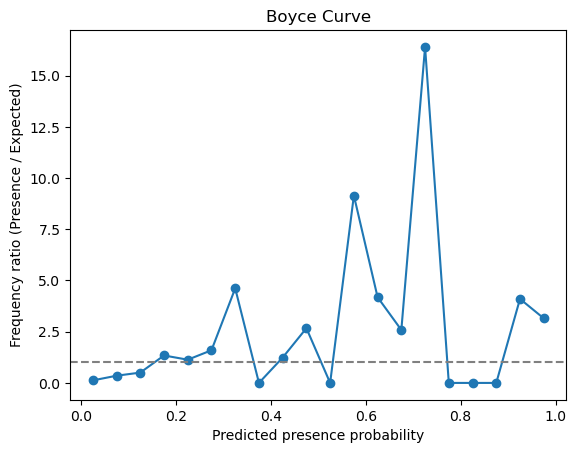

In [46]:
plot_boyce_curve(bg_values, presence_vals)

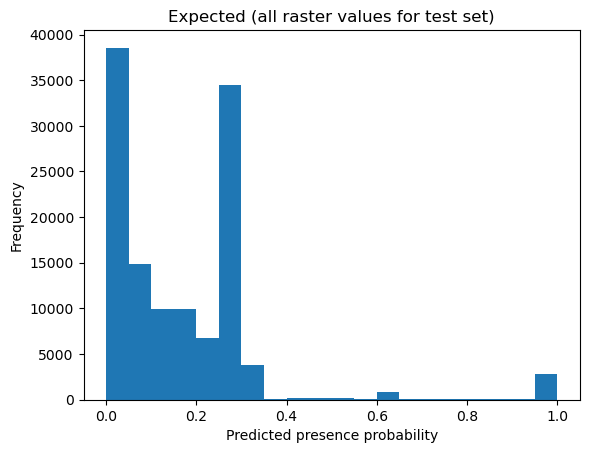

In [49]:
plt.hist(bg_values, bins=20)
plt.xlabel('Predicted presence probability')
plt.ylabel('Frequency')
plt.title('Expected (all raster values for test set)')
plt.savefig(os.path.join(FIGURES_DIR, 'boyce_expected_xgb'))

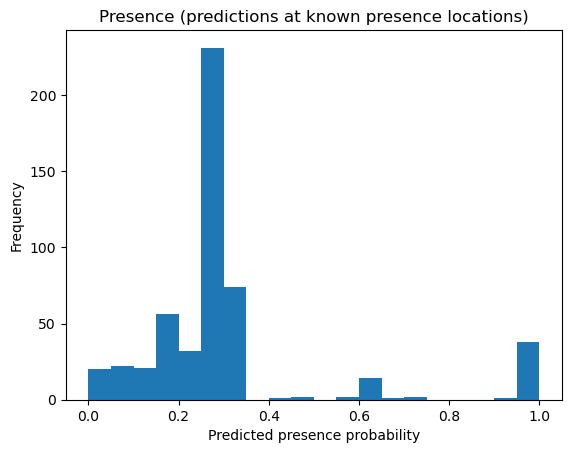

In [50]:
plt.hist(presence_vals, bins=20)
plt.xlabel('Predicted presence probability')
plt.ylabel('Frequency')
plt.title('Presence (predictions at known presence locations)')
plt.savefig(os.path.join(FIGURES_DIR, 'boyce_presence_xgb'))

## Other...

In [45]:
threshold_kde = 3.122

In [73]:
gridtile_accuracy = {}
gridtile_tp = {}
gridtile_fp = {}
gridtile_fn = {}
gridtile_tn = {}

for tile_grid in test_data['tile_grid'].unique():
    tileId = tile_grid[:5]
    grid_id = int(tile_grid[5:])

    ds = data_tiles_all[tileId]
    ds_pred = pred_tiles_all[tileId]

    if not hasattr(ds_data, 'ZM_Gauss'):
        continue

    print(f"Processing {tile_grid}")

    mask = ds['grid_id'] == grid_id
    mask_indices = np.where(mask)
    y_min, y_max = mask_indices[0].min(), mask_indices[0].max()
    x_min, x_max = mask_indices[1].min(), mask_indices[1].max()

    # Predictions
    pred = ds_pred['pred'].isel(
        y=slice(y_min, y_max),
        x=slice(x_min, x_max)
    ).values

    # Ground truth
    ds_slice = ds.isel(
        y=slice(y_min, y_max),
        x=slice(x_min, x_max)
    )
    
    presence_cond = ds_slice['ZM_Gauss'] >= 0.8
    absence_cond = (ds_slice['ZM_Gauss'] < 0.05)&(ds_slice['SurveyKDE'] > threshold_kde)&(ds_slice['bathymetry'] > -15.0)&(ds_slice['bathymetry'] < 0.0)
    
    gt = np.full((ds_slice.sizes['y'], ds_slice.sizes['x']), np.nan, dtype=np.float32)
    gt[presence_cond] = 1
    gt[absence_cond] = 0
    gt[np.isnan(pred)] = np.nan
    
    total_pixels = (~np.isnan(gt)).sum().item()
    if total_pixels == 0:
        continue

    tp_sum = ((gt == 1) & (pred == 1)).sum().item()
    fp_sum = ((gt == 0) & (pred == 1)).sum().item()
    fn_sum = ((gt == 1) & (pred == 0)).sum().item()
    tn_sum = ((gt == 0) & (pred == 0)).sum().item()

    gridtile_tp[tile_grid] = tp_sum
    gridtile_fp[tile_grid] = fp_sum
    gridtile_fn[tile_grid] = fn_sum
    gridtile_tn[tile_grid] = tn_sum
    gridtile_accuracy[tile_grid] = (tp_sum + tn_sum) / total_pixels

    del ds
    del ds_pred
    del mask
    del pred
    del gt

Processing 29UPR4
Processing 29VPC75
Processing 29VPC19
Processing 29VPE29
Processing 30UUA32
Processing 30UUA20
Processing 30UUA13
Processing 30UUA21
Processing 30UUA14
Processing 30UUA40
Processing 30UUA11
Processing 30UUC7
Processing 30UUC13
Processing 30UUD5
Processing 30UUF20
Processing 30UUG44
Processing 30UUG52
Processing 30UUG53
Processing 30UVA5
Processing 30UWB21


MemoryError: Unable to allocate 115. MiB for an array with shape (5490, 5490) and data type int32

In [82]:
for tile_grid in gridtile_accuracy:
    print((
        f"{tile_grid}: "
        f"Acc: {gridtile_accuracy[tile_grid]}, "
        f"TP: {gridtile_tp[tile_grid]}, "
        f"FP: {gridtile_fp[tile_grid]}, "
        f"FN: {gridtile_fn[tile_grid]}, "
        f"TN: {gridtile_tn[tile_grid]}"
    ))

29UPR4: Acc: 0.9938650306748467, TP: 0, FP: 7, FN: 0, TN: 1134
29VPC75: Acc: 0.9973753280839895, TP: 0, FP: 20, FN: 0, TN: 7600
29VPC19: Acc: 0.13333333333333333, TP: 2, FP: 0, FN: 13, TN: 0
29VPE29: Acc: 0.5, TP: 2, FP: 0, FN: 2, TN: 0
30UUA32: Acc: 0.9983996206508209, TP: 0, FP: 27, FN: 0, TN: 16844
30UUA20: Acc: 0.9886646736422521, TP: 0, FP: 182, FN: 0, TN: 15874
30UUA13: Acc: 0.9979176677879225, TP: 0, FP: 13, FN: 0, TN: 6230
30UUA21: Acc: 0.9727208729320662, TP: 0, FP: 155, FN: 0, TN: 5527
30UUA14: Acc: 0.9845804252556403, TP: 0, FP: 95, FN: 0, TN: 6066
30UUA40: Acc: 1.0, TP: 0, FP: 0, FN: 0, TN: 2260
30UUA11: Acc: 1.0, TP: 0, FP: 0, FN: 0, TN: 1098
30UUC7: Acc: 0.9792273344981557, TP: 0, FP: 107, FN: 0, TN: 5044
30UUC13: Acc: 0.8890975504055142, TP: 0, FP: 5372, FN: 2, TN: 43083
30UUD5: Acc: 0.9043394613082514, TP: 0, FP: 895, FN: 0, TN: 8461
30UUF20: Acc: 0.8, TP: 4, FP: 0, FN: 1, TN: 0
30UUG44: Acc: 0.875, TP: 0, FP: 10, FN: 0, TN: 70
30UUG52: Acc: 0.9863013698630136, TP: 0, F

In [83]:
tp_vals = np.array(list(gridtile_tp.values()))
fp_vals = np.array(list(gridtile_fp.values()))
fn_vals = np.array(list(gridtile_fn.values()))
tn_vals = np.array(list(gridtile_tn.values()))

overall_accuracy = tp_vals.sum() + tn_vals.sum()
overall_accuracy /= (tp_vals + fp_vals + fn_vals + tn_vals).sum()

overall_precision = tp_vals.sum() / (tp_vals.sum() + fp_vals.sum())
overall_recall = tp_vals.sum() / (tp_vals.sum() + fn_vals.sum())
overall_f1 = 2 * overall_precision * overall_recall / (overall_precision + overall_recall)

In [84]:
print(f"Overall Accuracy: {overall_accuracy:.3f}")
print(f"Overall Precision: {overall_precision:.3f}")
print(f"Overall Recall: {overall_recall:.3f}")
print(f"Overall F1-score: {overall_f1:.3f}")

Overall Accuracy: 0.959
Overall Precision: 0.001
Overall Recall: 0.308
Overall F1-score: 0.002


In [85]:
example_tiles = ['29UPR2', '29UPR5', '30UUA25']

In [86]:
import matplotlib.pyplot as plt

In [87]:
FIGURES_DIR = '../saved_figures'

In [89]:
gridtile_accuracy_examples = {}
gridtile_tp_examples = {}
gridtile_fp_examples = {}
gridtile_fn_examples = {}
gridtile_tn_examples = {}

for tile_grid in example_tiles:
    tileId = tile_grid[:5]
    grid_id = int(tile_grid[5:])

    ds = data_tiles_all[tileId]
    ds_pred = pred_tiles_all[tileId]

    if not hasattr(ds_data, 'ZM_Gauss'):
        continue

    print(f"Processing {tile_grid}")

    mask = ds['grid_id'] == grid_id
    mask_indices = np.where(mask)
    y_min, y_max = mask_indices[0].min(), mask_indices[0].max()
    x_min, x_max = mask_indices[1].min(), mask_indices[1].max()

    # Predictions
    pred = ds_pred['pred'].isel(
        y=slice(y_min, y_max),
        x=slice(x_min, x_max)
    ).values

    # Ground truth
    ds_slice = ds.isel(
        y=slice(y_min, y_max),
        x=slice(x_min, x_max)
    )
    
    presence_cond = ds_slice['ZM_Gauss'] >= 0.8
    absence_cond = (ds_slice['ZM_Gauss'] < 0.05)&(ds_slice['SurveyKDE'] > threshold_kde)&(ds_slice['bathymetry'] > -15.0)&(ds_slice['bathymetry'] < 0.0)
    
    gt = np.full((ds_slice.sizes['y'], ds_slice.sizes['x']), np.nan, dtype=np.float32)
    gt[presence_cond] = 1
    gt[absence_cond] = 0
    gt[np.isnan(pred)] = np.nan
    
    total_pixels = (~np.isnan(gt)).sum().item()
    if total_pixels == 0:
        continue

    tp_sum = ((gt == 1) & (pred == 1)).sum().item()
    fp_sum = ((gt == 0) & (pred == 1)).sum().item()
    fn_sum = ((gt == 1) & (pred == 0)).sum().item()
    tn_sum = ((gt == 0) & (pred == 0)).sum().item()

    gridtile_tp_examples[tile_grid] = tp_sum
    gridtile_fp_examples[tile_grid] = fp_sum
    gridtile_fn_examples[tile_grid] = fn_sum
    gridtile_tn_examples[tile_grid] = tn_sum
    gridtile_accuracy_examples[tile_grid] = (tp_sum + tn_sum) / total_pixels

    del ds
    del ds_pred
    del mask
    del pred
    del gt

Processing 29UPR2
Processing 29UPR5
Processing 30UUA25


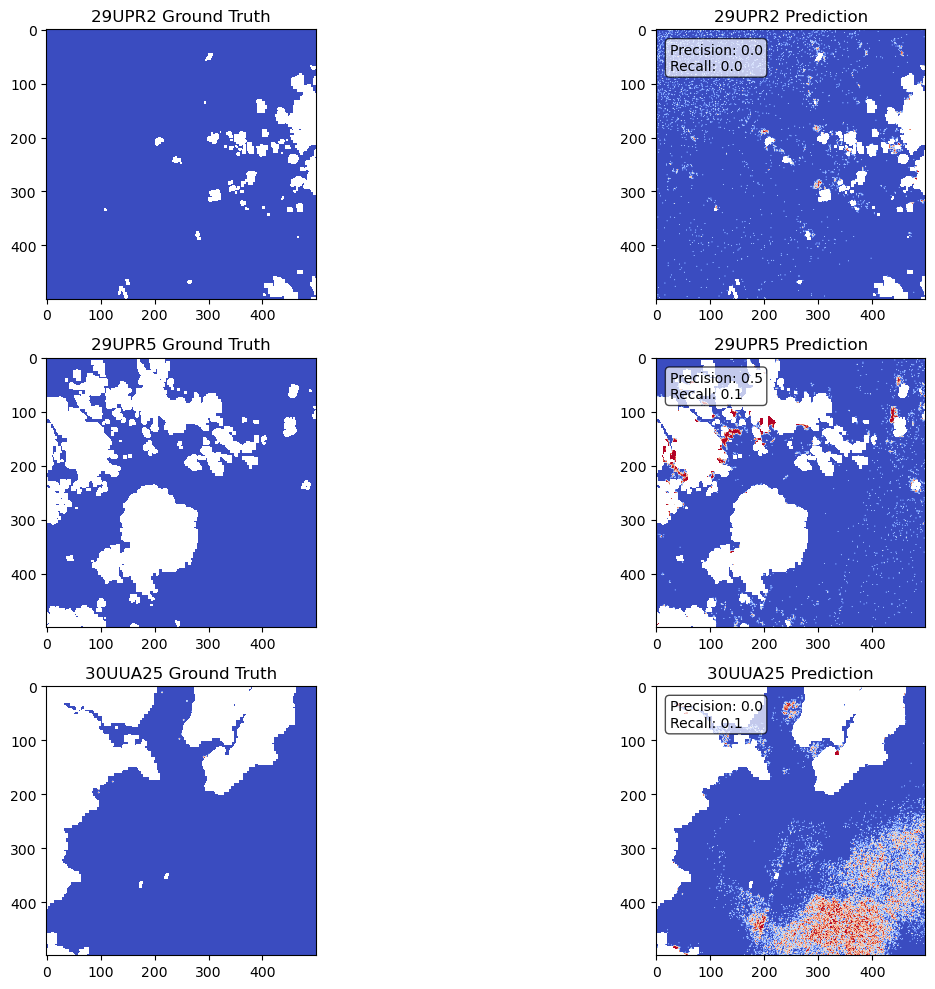

In [98]:
fig, axs = plt.subplots(3, 2, figsize=(15, 10))

for i, tile_grid in enumerate(example_tiles):
    tileId = tile_grid[:5]
    grid_id = int(tile_grid[5:])
    accuracy = gridtile_accuracy_examples[tile_grid]
    tp = gridtile_tp_examples[tile_grid]
    fp = gridtile_fp_examples[tile_grid]
    fn = gridtile_fn_examples[tile_grid]
    tn = gridtile_tn_examples[tile_grid]
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    
    ds = data_tiles_all[tileId]
    ds_pred = pred_tiles_all[tileId]
    
    mask = ds['grid_id'] == grid_id
    mask_indices = np.where(mask)
    y_min, y_max = mask_indices[0].min(), mask_indices[0].max()
    x_min, x_max = mask_indices[1].min(), mask_indices[1].max()

    # Predictions
    pred = ds_pred['pred'].isel(
        y=slice(y_min, y_max),
        x=slice(x_min, x_max)
    ).values

    # Ground truth
    grid_data = ds_data['ZM_Gauss'].isel(
        y=slice(y_min, y_max),
        x=slice(x_min, x_max)
    )
    gt = xr.where(grid_data >= 0.8, 1, 0).where(~np.isnan(pred))
    
    # Plot
    axs[i, 0].imshow(gt, cmap='coolwarm', vmin=0, vmax=1)
    axs[i, 0].set_title(f"{tile_grid} Ground Truth")

    im2 = axs[i, 1].imshow(pred, cmap='coolwarm', vmin=0, vmax=1)
    axs[i, 1].set_title(f"{tile_grid} Prediction")
    axs[i, 1].text(
        0.05, 0.95,
        f"Precision: {precision:.1f}\nRecall: {recall:.1f}",
        transform=axs[i, 1].transAxes,
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, 'pred_examples'), dpi=300)
plt.show()

In [100]:
gt_thresholds = [0.05, 0.05, 0.8, 0.9]
N_gt = len(gt_thresholds)

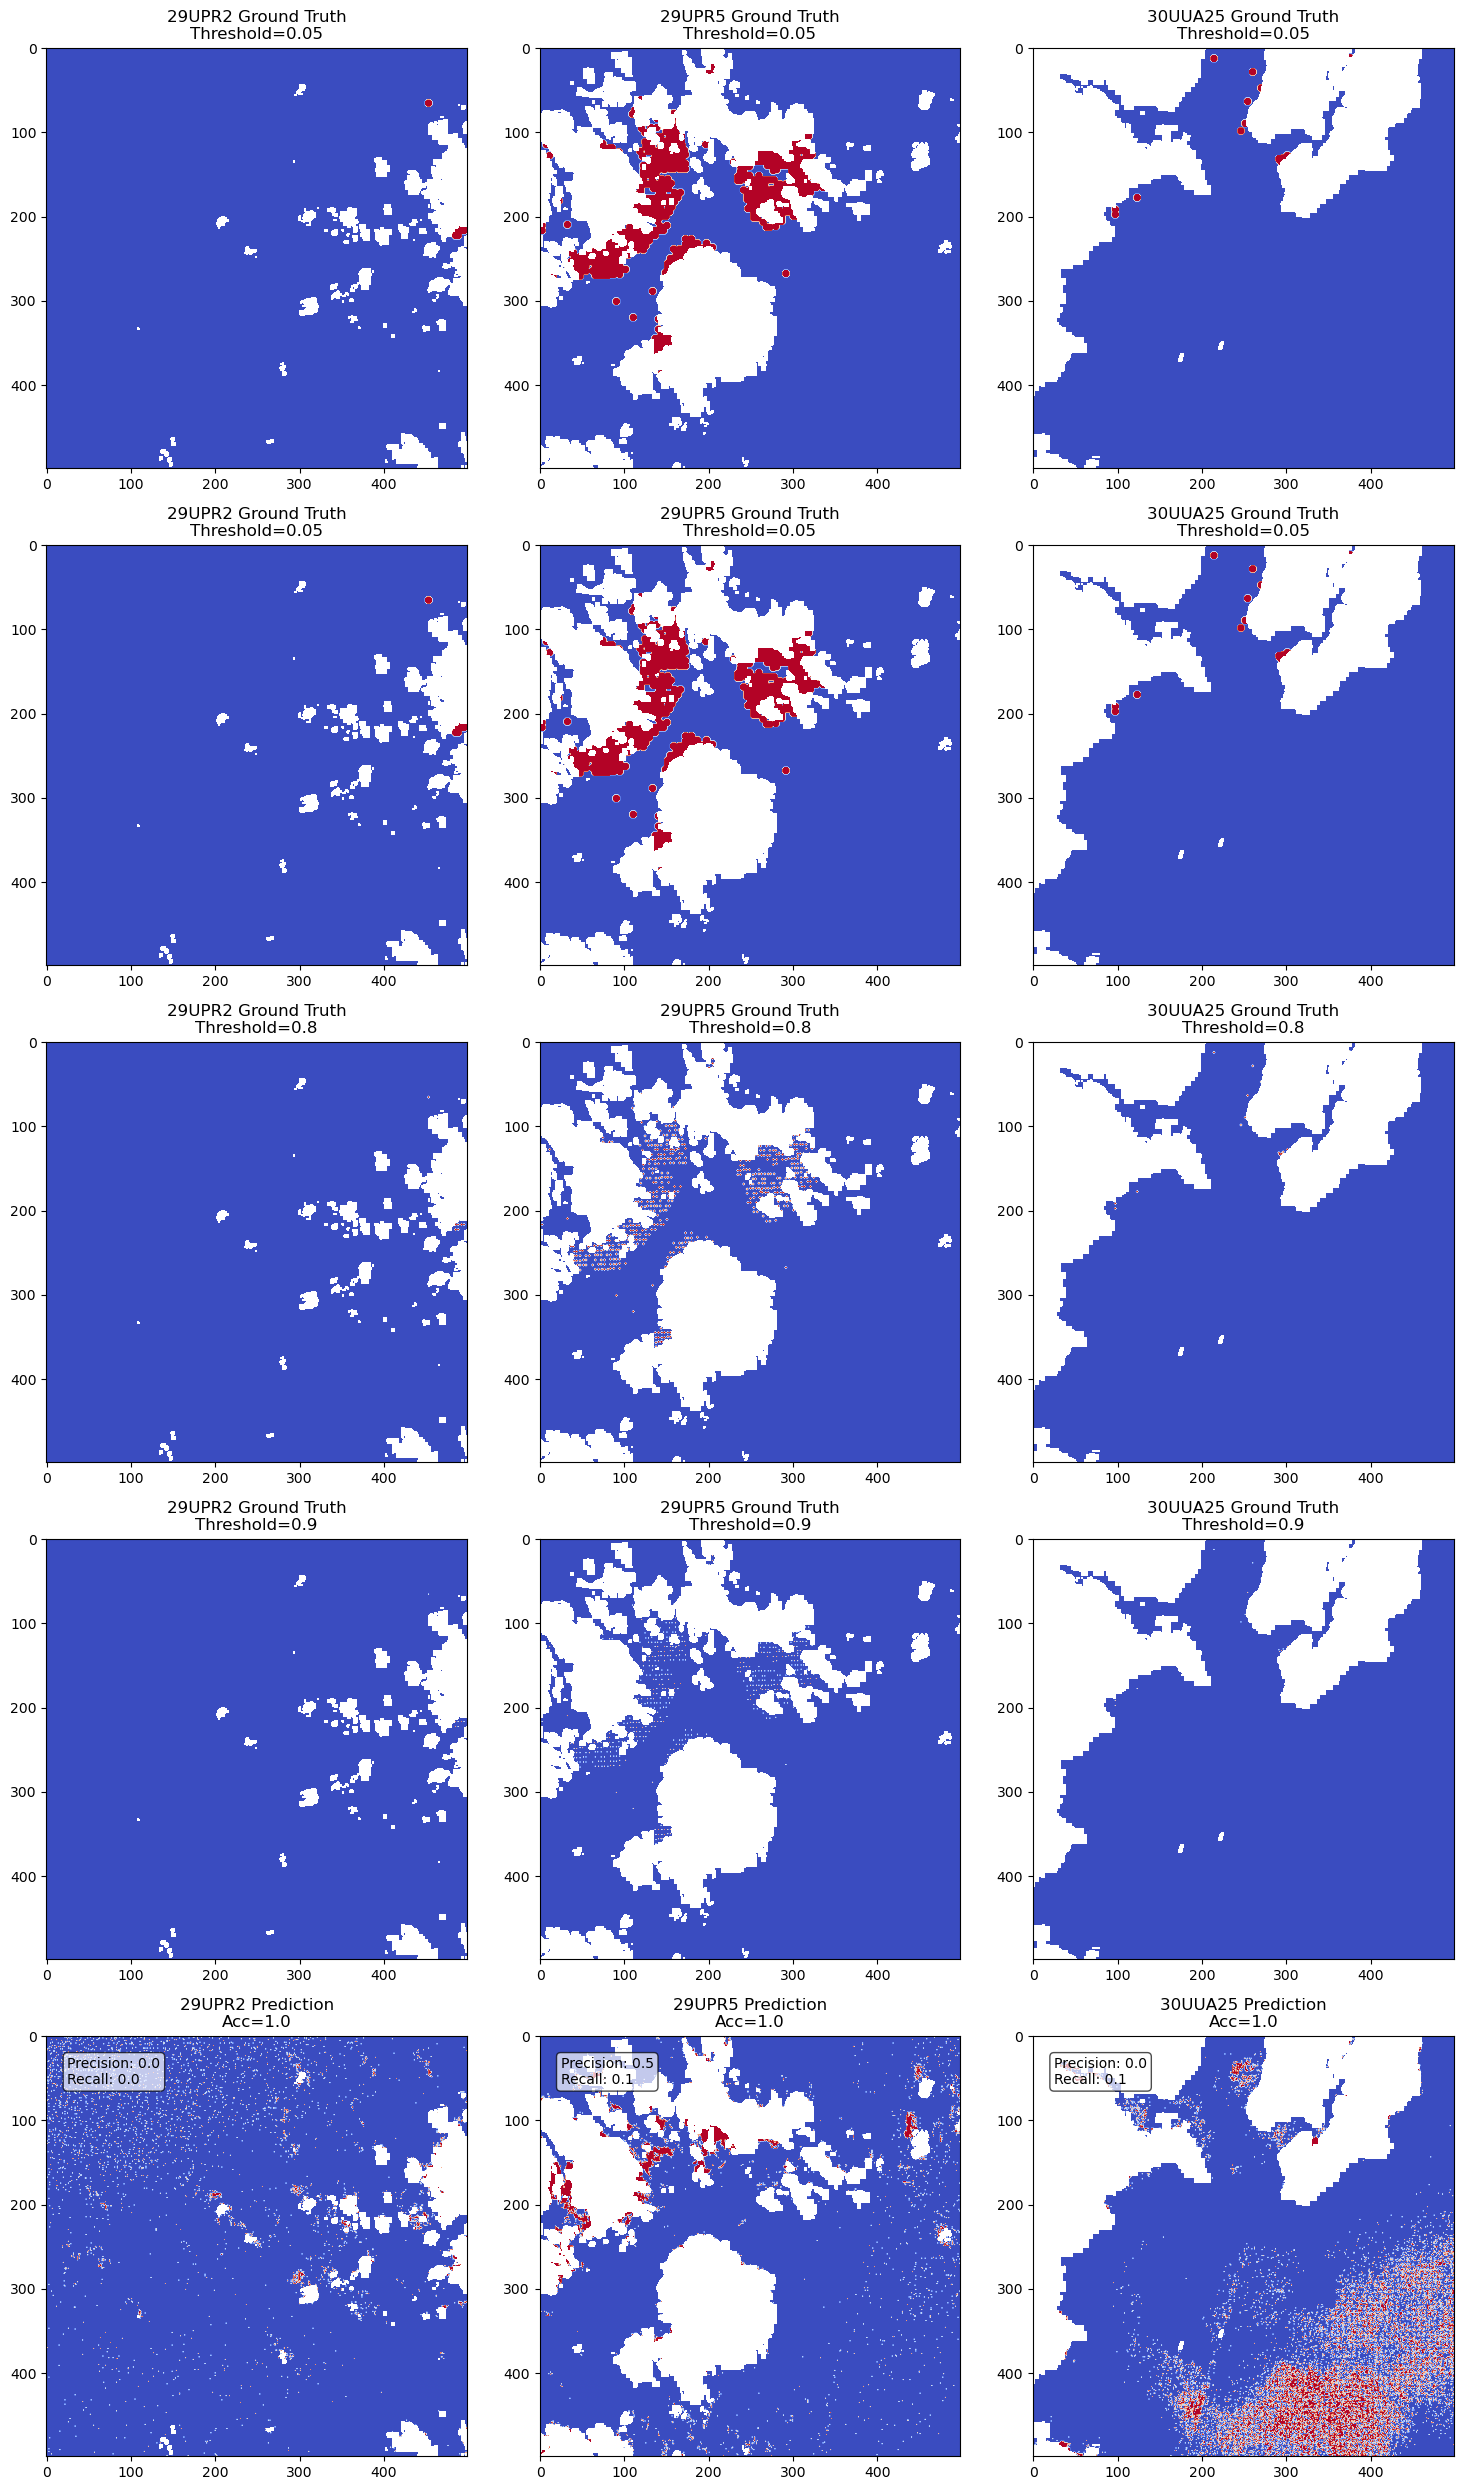

In [101]:
fig, axs = plt.subplots(N_gt+1, 3, figsize=(15, 25))

for i, tile_grid in enumerate(example_tiles):
    tileId = tile_grid[:5]
    grid_id = int(tile_grid[5:])
    accuracy = gridtile_accuracy_examples[tile_grid]
    tp = gridtile_tp_examples[tile_grid]
    fp = gridtile_fp_examples[tile_grid]
    fn = gridtile_fn_examples[tile_grid]
    tn = gridtile_tn_examples[tile_grid]
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    
    ds_data = data_tiles_all[tileId]
    ds_pred = pred_tiles_all[tileId]
    
    mask = ds_data['grid_id'] == grid_id
    mask_indices = np.where(mask)
    y_min, y_max = mask_indices[0].min(), mask_indices[0].max()
    x_min, x_max = mask_indices[1].min(), mask_indices[1].max()

    # Predictions
    pred = ds_pred['pred'].isel(
        y=slice(y_min, y_max),
        x=slice(x_min, x_max)
    ).values

    grid_data = ds_data['ZM_Gauss'].isel(
        y=slice(y_min, y_max),
        x=slice(x_min, x_max)
    )

    for j in range(N_gt):
        # Ground truth
        gt = xr.where(grid_data >= gt_thresholds[j], 1, 0).where(~np.isnan(pred))
    
        # Plot
        axs[j, i].imshow(gt, cmap='coolwarm', vmin=0, vmax=1)
        axs[j, i].set_title(f"{tile_grid} Ground Truth\nThreshold={gt_thresholds[j]}")

    im2 = axs[N_gt, i].imshow(pred, cmap='coolwarm', vmin=0, vmax=1)
    axs[N_gt, i].set_title(f"{tile_grid} Prediction\nAcc={accuracy:.1f}")
    axs[N_gt, i].text(
        0.05, 0.95,
        f"Precision: {precision:.1f}\nRecall: {recall:.1f}",
        transform=axs[N_gt, i].transAxes,
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pred_examples'), dpi=300)
plt.show()